# Anime Analysis

# Libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset

In [91]:
df = pd.read_csv('anime.csv')
df.head()

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


# EDA

In [93]:
# Extract Anime Type (TV, Movie, OVA)
df['Type'] = df['Title'].str.extract(r'(TV|Movie|OVA)')

In [94]:
# Extract Episode Count
df['Episode'] = df['Title'].str.extract(r'\((\d+)\s*eps\)')


In [95]:
#  Extract Clean Anime Title (remove type & eps info)
df['Anime_Name']  = df['Title'].str.extract(r'^([^(]+)')


In [96]:
# Add ‘Year’ Column (if needed for analysis)
df['Year'] = df['Title'].str.extract(r'(\d{4})')

In [97]:
df = df.drop(columns = ['Title'])

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        50 non-null     int64  
 1   Score       50 non-null     float64
 2   Type        49 non-null     object 
 3   Episode     50 non-null     object 
 4   Anime_Name  50 non-null     object 
 5   Year        50 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 2.5+ KB


In [99]:
df['Episode'] = pd.to_numeric(df['Episode'],errors = 'coerce')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        50 non-null     int64  
 1   Score       50 non-null     float64
 2   Type        49 non-null     object 
 3   Episode     50 non-null     int64  
 4   Anime_Name  50 non-null     object 
 5   Year        50 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 2.5+ KB


In [113]:
# Remove trailing 'TV', 'Movie', or 'OVA' (with or without spaces before them)
df['Anime_Name'] = df['Anime_Name'].str.replace(r'(TV|Movie|OVA)\s*$', '', regex=True).str.strip()
df.head()

,Rank,Score,Type,Episode,Anime_Name,Year
0,1,9.10,TV,64,Fullmetal Alchemist: Brotherhood,2009
1,2,9.07,TV,24,Steins;Gate,2011
2,3,9.06,TV,13,Bleach: Sennen Kessen-hen,2022
3,4,9.06,TV,51,Gintama°,2015
4,5,9.05,TV,10,Shingeki no Kyojin Season 3 Part 2,2019


# Visualization Now!

C:\Users\asus\AppData\Local\Temp\ipykernel_15080\591123430.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_10,x = 'Score',y ='Anime_Name',palette = 'magma')


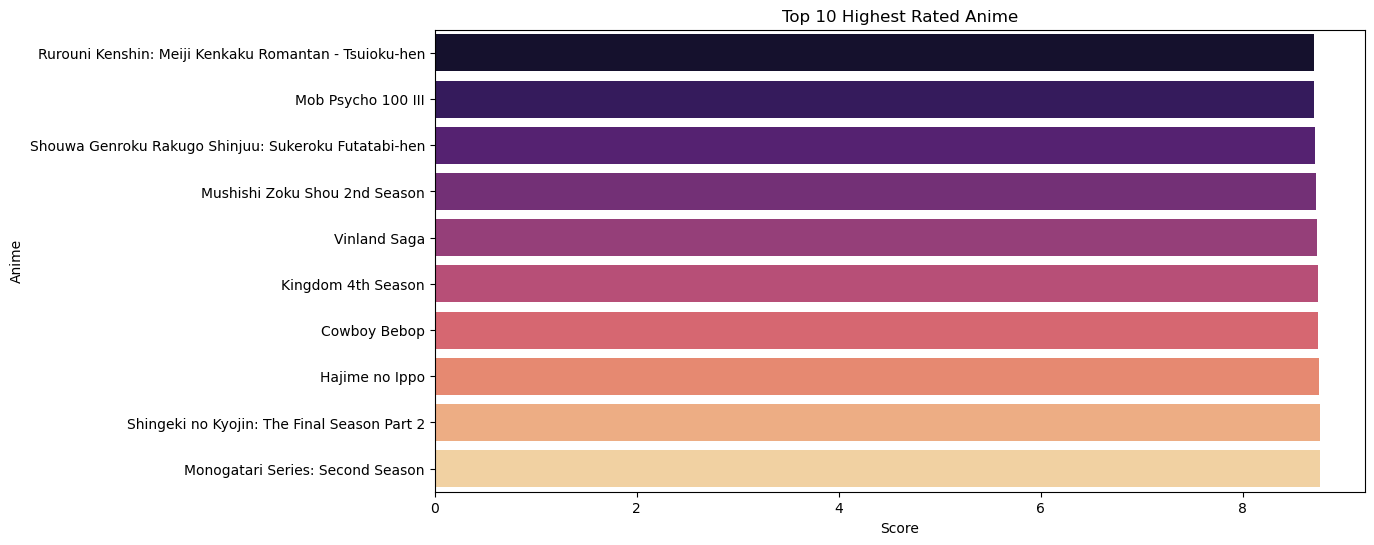

In [114]:
# Top 10 Highest Rated Anime

top_10 = df.sort_values(by = 'Score',ascending = True).head(10)
top_10

plt.figure(figsize=(12,6))
sns.barplot(data = top_10,x = 'Score',y ='Anime_Name',palette = 'magma')
plt.title('Top 10 Highest Rated Anime')
plt.xlabel('Score')
plt.ylabel('Anime')
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_15080\3366005061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'Type',palette= 'viridis',order = df['Type'].value_counts().index)


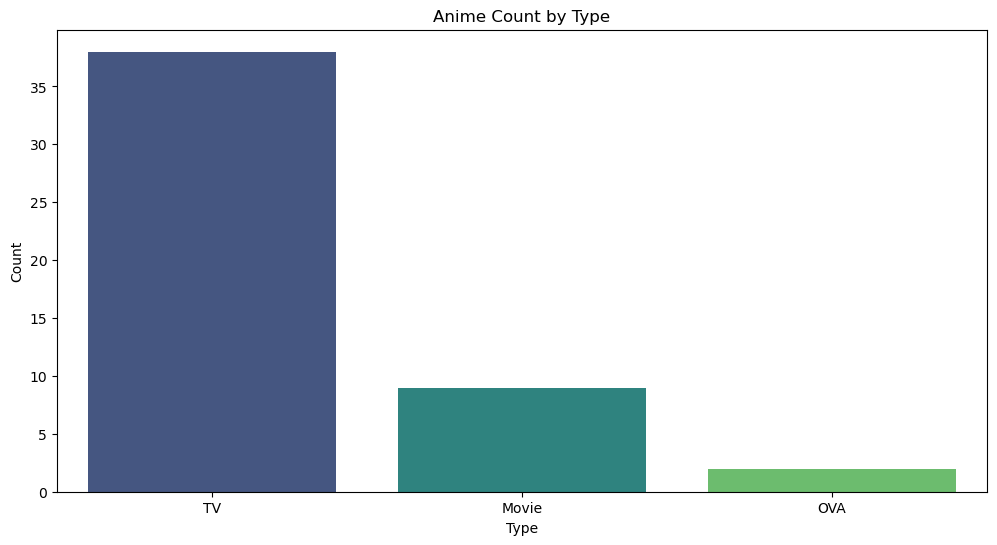

In [117]:
# Anime Count by Type (Countplot)
plt.figure(figsize= (12,6))
sns.countplot(data = df, x= 'Type',palette= 'viridis',order = df['Type'].value_counts().index)
plt.title('Anime Count by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

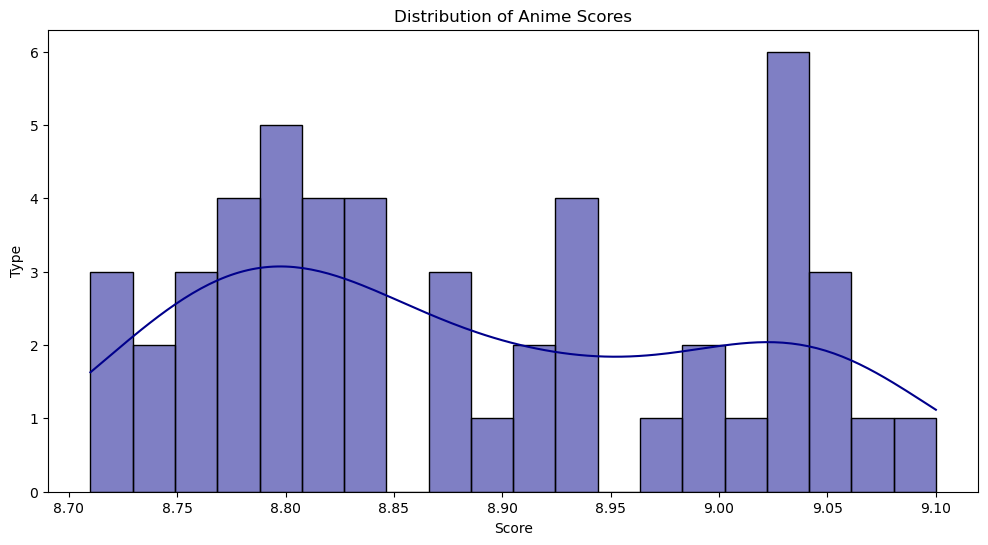

In [118]:
# Distribution of Scores (Histogram + KDE)
plt.figure(figsize = (12,6))
sns.histplot(df['Score'],bins = 20 ,kde = True,color= 'darkblue')
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Type')
plt.show()

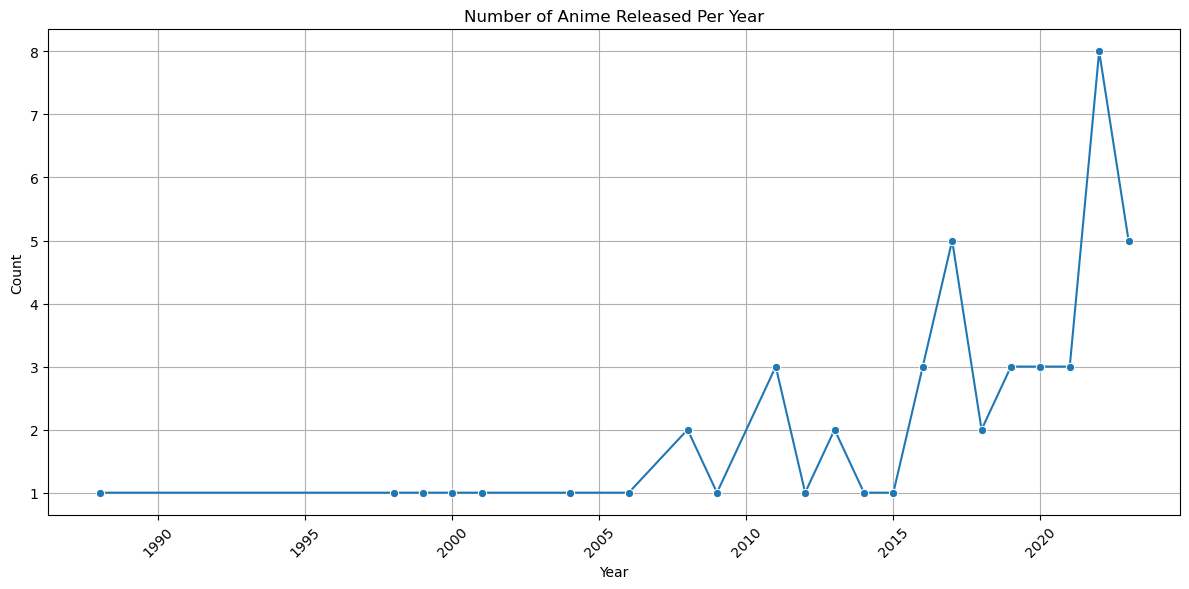

In [125]:
# Anime Releases per Year (Line Plot)
df['Year'] = pd.to_numeric(df['Year'],errors = 'coerce')

yearly_count = df['Year'].value_counts().sort_index()

plt.figure(figsize= (12,6))
sns.lineplot(x = yearly_count.index, y = yearly_count.values,marker = 'o')
plt.title('Number of Anime Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_15080\1495273583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_episodes,x = 'Episode',y = 'Anime_Name',palette = 'coolwarm')


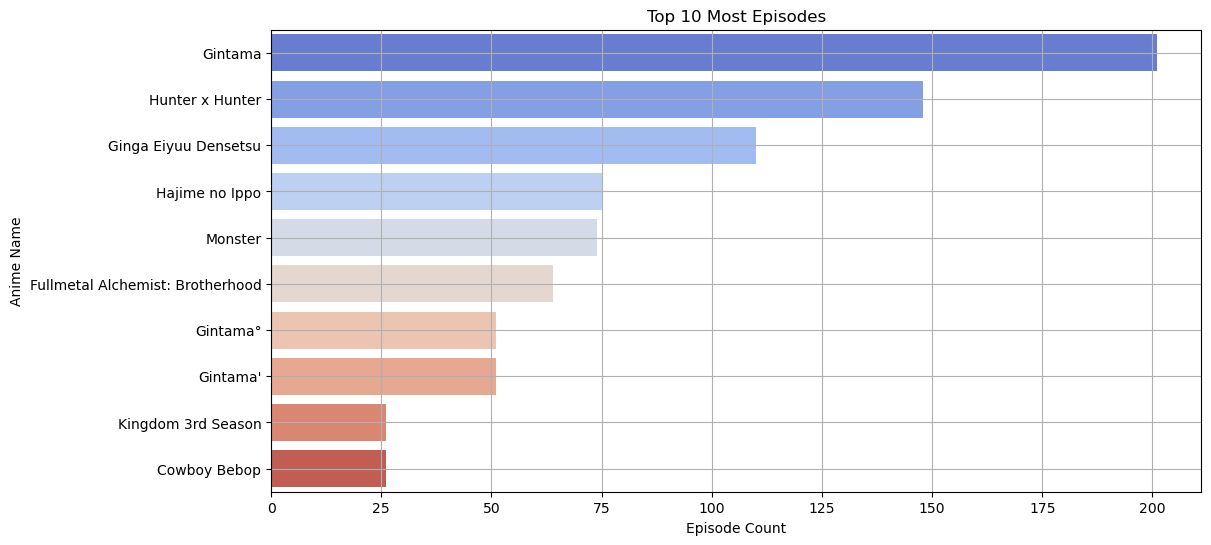

In [134]:
# Top 10 Most Episodes
 


top_episodes = df.sort_values(by = 'Episode',ascending = False).head(10)

plt.figure(figsize = (12,6))
sns.barplot(data = top_episodes,x = 'Episode',y = 'Anime_Name',palette = 'coolwarm')
plt.title('Top 10 Most Episodes')
plt.xlabel('Episode Count')
plt.ylabel('Anime Name')
plt.grid(True)
plt.show()